In [1]:
import yfinance as yf

In [2]:
sp500 = yf.Ticker("^GSPC") # enable to download price history for single symbol

In [3]:
sp500 = sp500.history(period="max") # import all data from begining

sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2023-03-16 00:00:00-04:00,3878.929932,3964.459961,3864.110107,3960.280029,5695790000,0.0,0.0
2023-03-17 00:00:00-04:00,3958.689941,3958.909912,3901.270020,3916.639893,9354280000,0.0,0.0
2023-03-20 00:00:00-04:00,3917.469971,3956.620117,3916.889893,3951.570068,5347140000,0.0,0.0


In [4]:
import matplotlib.pyplot as plt

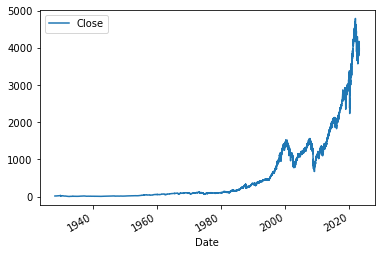

In [5]:
sp500.plot.line(y="Close" , use_index = True);

In [6]:
#delete unnecessary columns

del sp500["Dividends"]
del sp500["Stock Splits"]

In [7]:
# shift method to shift one value back for new column tomorrow

sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [8]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2023-03-16 00:00:00-04:00,3878.929932,3964.459961,3864.110107,3960.280029,5695790000,3916.639893
2023-03-17 00:00:00-04:00,3958.689941,3958.909912,3901.270020,3916.639893,9354280000,3951.570068
2023-03-20 00:00:00-04:00,3917.469971,3956.620117,3916.889893,3951.570068,5347140000,4002.870117


In [9]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

#tomorrow price greater than today, boolean type convert in int

In [10]:
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0


In [11]:
# remove data before 1990

sp500 = sp500["1990-01-01 00:00:00-05:00":].copy()

In [12]:
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0


In [13]:
sp500.shape

(8370, 7)

In [14]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators = no. of D trees, min_samples_split = protect overfitting, random_state = re run model twice we get same result

model = RandomForestClassifier(n_estimators=100 , min_samples_split= 100 , random_state=1)

train = sp500.iloc[:-100] # except last 100 rows
test = sp500.iloc[-100:] # last 100 rows in test data

predictors = ["Close", "Volume", "Open", "High", "Low"]

#Train model in order of predictor column to predict target
model.fit(train[predictors], train["Target"])

C:\Users\ADMIN\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


RandomForestClassifier(min_samples_split=100, random_state=1)

In [15]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])

preds

array([0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1])

In [16]:
import pandas as pd

preds = pd.Series(preds , index = test.index)

preds

Date
2022-10-27 00:00:00-04:00    0
2022-10-28 00:00:00-04:00    1
2022-10-31 00:00:00-04:00    1
2022-11-01 00:00:00-04:00    0
2022-11-02 00:00:00-04:00    1
                            ..
2023-03-16 00:00:00-04:00    1
2023-03-17 00:00:00-04:00    1
2023-03-20 00:00:00-04:00    0
2023-03-21 00:00:00-04:00    1
2023-03-22 00:00:00-04:00    1
Length: 100, dtype: int32

In [17]:
precision_score(test["Target"], preds)

0.3508771929824561

In [18]:
# concate method join the column from test[target] with predict values
combined = pd.concat([test["Target"], preds], axis=1)

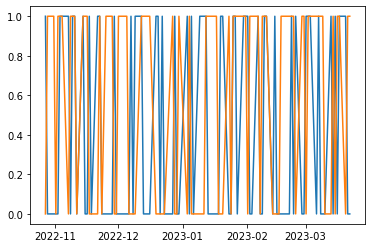

In [19]:
plt.plot(combined);

In [20]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = preds = pd.Series(preds , index = test.index, name="Prediction")
    combined = pd.concat([test["Target"], preds] , axis=1)
    return combined

In [21]:
def backtest(data , model, predictors, start = 2500, step = 250):
    
    all_prediction = []
    
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test  = data.iloc[i: i+step].copy()
        prediction = predict(train, test, predictors, model)
        all_prediction.append(prediction)
    return pd.concat(all_prediction)

In [22]:
predictions = backtest(sp500 , model , predictors)

In [23]:
predictions["Prediction"].value_counts()

0    3406
1    2464
Name: Prediction, dtype: int64

In [24]:
predictions.head() 

,Target,Prediction
Date,,
1999-11-22 00:00:00-05:00,0,0
1999-11-23 00:00:00-05:00,1,0
1999-11-24 00:00:00-05:00,0,0
1999-11-26 00:00:00-05:00,0,0
1999-11-29 00:00:00-05:00,0,0


In [25]:
precision_score(predictions["Target"] , predictions["Prediction"])

0.5271915584415584

In [26]:
(predictions["Target"].value_counts() / predictions.shape[0]) * 100

1    53.356048
0    46.643952
Name: Target, dtype: float64

In [27]:
horizons = [2, 5, 60, 250, 1000]
new_predictors = []

for h in horizons:
    rolling_average = sp500.rolling(h).mean()
    
    ratio_column = f"Close_ratio{h}"
    sp500[ratio_column] = sp500["Close"] / rolling_average["Close"]
    
    trend_column = f"Trend_{h}"
    sp500[trend_column] = sp500.shift(1).rolling(h).sum()["Target"]
    
    new_predictors += [ratio_column, trend_column]

In [28]:
sp500 = sp500.dropna()
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_ratio2,Trend_2,Close_ratio5,Trend_5,Close_ratio60,Trend_60,Close_ratio250,Trend_250,Close_ratio1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0


In [29]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds > 0.5] = 1
    preds[preds <= 0.5] = 0
    preds = preds = pd.Series(preds , index = test.index, name="Prediction")
    combined = pd.concat([test["Target"], preds] , axis=1)
    return combined

In [30]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [31]:
predictions = backtest(sp500, model, new_predictors)

In [33]:
predictions["Prediction"].value_counts()

1.0    3453
0.0    1416
Name: Prediction, dtype: int64

In [36]:
precision_score(predictions["Target"], predictions["Prediction"])

0.5522733854619172